# Análise dos Add-ons da Regressão Logística

Este notebook explica o que o script `analyze_addon_performance.py` faz e interpreta os resultados guardados em `outputs/addon_performance`.

A lógica é a seguinte:

1. perceber o problema de machine learning;
2. perceber o que cada add-on tenta corrigir;
3. perceber como o script compara os modelos;
4. olhar para os resultados com gráficos e testes estatísticos;
5. tirar uma conclusão equilibrada, sem esconder os compromissos.

A regra principal é simples: num conjunto de dados desequilibrado, um modelo pode parecer bom só porque acerta quase sempre na classe maioritária. Por isso, a pergunta real não é apenas "qual tem maior accuracy?", mas sim "qual encontra melhor a classe minoritária sem estragar demasiado o resto?".

## 1. Carregar os resultados

O script já foi executado. Aqui só leio os ficheiros CSV e JSON produzidos por essa execução.

Os ficheiros mais importantes são:

- `raw_results.csv`: uma linha por dataset, seed e modelo treinado com sucesso;
- `model_summary.csv`: médias, medianas e desvios-padrão por modelo;
- `paired_tests_vs_default.csv`: comparação estatística entre cada add-on e o modelo `default`;
- `dataset_summary.csv`: melhor modelo por dataset e por métrica;
- `errors.csv`: execuções que falharam;
- `config.json`: hiperparâmetros usados na experiência.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "addon_performance"

raw_results = pd.read_csv(OUTPUT_DIR / "raw_results.csv")
model_summary = pd.read_csv(OUTPUT_DIR / "model_summary.csv")
paired_tests = pd.read_csv(OUTPUT_DIR / "paired_tests_vs_default.csv")
dataset_summary = pd.read_csv(OUTPUT_DIR / "dataset_summary.csv")
errors = pd.read_csv(OUTPUT_DIR / "errors.csv") if (OUTPUT_DIR / "errors.csv").exists() else pd.DataFrame()

with (OUTPUT_DIR / "config.json").open(encoding="utf-8") as file:
    config = json.load(file)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", 100)

In [2]:
summary = pd.DataFrame(
    [
        {"item": "datasets", "value": raw_results["dataset"].nunique()},
        {"item": "seeds", "value": raw_results["seed"].nunique()},
        {"item": "modelos", "value": raw_results["model"].nunique()},
        {"item": "execuções com sucesso", "value": len(raw_results)},
        {"item": "execuções com erro", "value": len(errors)},
        {"item": "pares dataset/seed com resultados", "value": raw_results[["dataset", "seed"]].drop_duplicates().shape[0]},
    ]
)

display(summary)
display(pd.DataFrame(config.get("analysis_config", config), index=["valor"]).T)

,item,value
0,datasets,20
1,seeds,20
2,modelos,16
3,execuções com sucesso,6160
4,execuções com erro,240
5,pares dataset/seed com resultados,385


,valor
cagd_alpha,5.0
cagd_approximation,diagonal
cagd_epsilon,0.01
focal_alpha,0.5
focal_gamma,2.0
gaar_c_minority,25.0
gaar_lambda,0.01
iterations,1000
learning_rate,0.01


## 2. O problema: desequilíbrio de classes

Vamos começar pela peça mais pequena: uma previsão binária.

Cada exemplo pertence a uma de duas classes:

- `target = 0`: classe maioritária;
- `target = 1`: classe minoritária, que aqui é a classe positiva.

Se tivermos 1000 exemplos e só 20 forem positivos, um modelo que prevê sempre `0` acerta em 980 exemplos. A accuracy seria 98%, mas o modelo encontrou exactamente 0 casos positivos. Para este tipo de problema, isso não é aceitável.

Por isso, uso métricas que obrigam o modelo a prestar atenção às duas classes:

- **majority recall**: de todos os exemplos da classe 0, quantos foram encontrados como 0;
- **minority recall**: de todos os exemplos da classe 1, quantos foram encontrados como 1;
- **balanced accuracy**: média dos dois recalls;
- **minority precision**: quando o modelo prevê 1, com que frequência acerta;
- **minority F1**: resumo entre precision e recall da classe minoritária.

A ideia de Feynman aqui é: se a accuracy pode ser alta ignorando a classe rara, então ela não mede bem aquilo que queremos. Balanced accuracy e F1 forçam-nos a olhar para a classe rara.

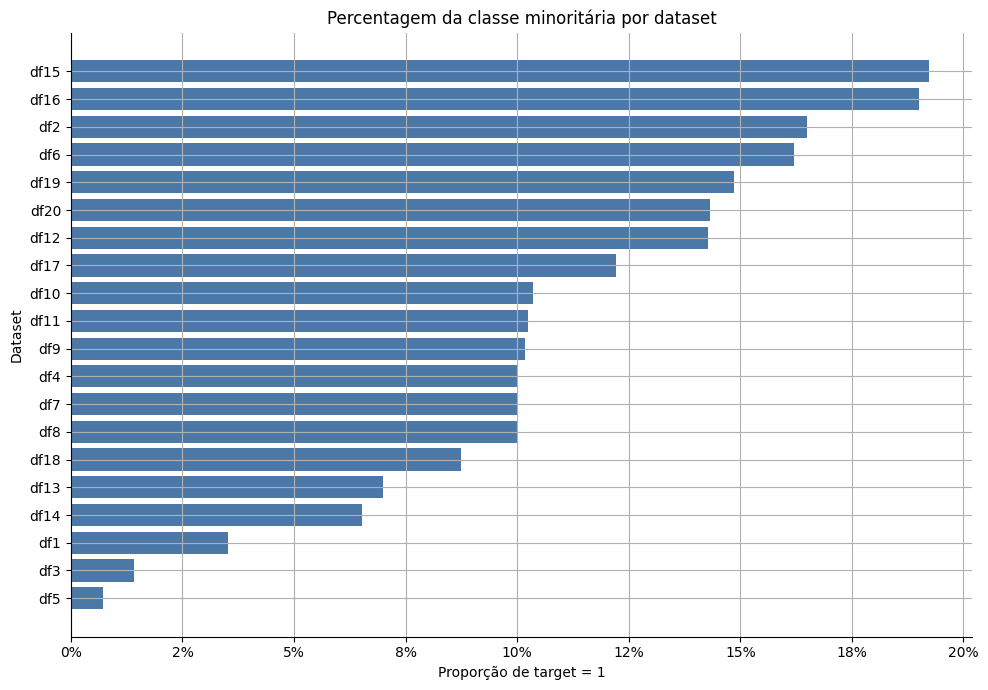

,dataset,target_0_count,target_1_count,rows,minority_ratio
1280,df5,9398,68,9466,0.0072
640,df3,2383,34,2417,0.0141
0,df1,4080,149,4229,0.0352
4160,df14,129,9,138,0.0652
3840,df13,93,7,100,0.0700
5440,df18,334,32,366,0.0874
2240,df8,1800,200,2000,0.1000
1920,df7,1800,200,2000,0.1000
960,df4,1800,200,2000,0.1000
2560,df9,5048,572,5620,0.1018


In [3]:
dataset_counts = (
    raw_results.drop_duplicates("dataset")
    [["dataset", "target_0_count", "target_1_count", "rows"]]
    .copy()
)
dataset_counts["minority_ratio"] = dataset_counts["target_1_count"] / dataset_counts["rows"]
dataset_counts = dataset_counts.sort_values("minority_ratio")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(dataset_counts["dataset"], dataset_counts["minority_ratio"], color="#4C78A8")
ax.set_title("Percentagem da classe minoritária por dataset")
ax.set_xlabel("Proporção de target = 1")
ax.set_ylabel("Dataset")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

display(dataset_counts.round(4))

## 3. O que o script `analyze_addon_performance.py` faz

O script faz uma comparação controlada. Em vez de treinar um modelo uma vez e confiar nesse resultado, ele repete a experiência em vários datasets e várias seeds.

Para cada dataset e seed, o processo é:

1. dividir os dados em treino, validação e teste;
2. treinar o modelo `default` e todos os modelos com add-ons;
3. avaliar todos no mesmo conjunto de teste;
4. guardar métricas como balanced accuracy, minority recall, minority F1, ROC AUC e average precision;
5. comparar cada add-on com o `default` no mesmo par dataset/seed.

Esta última parte é importante. A comparação é **emparelhada**: o modelo com add-on e o modelo `default` são comparados no mesmo dataset e na mesma seed. Assim, se uma divisão dos dados é mais difícil, ela afecta os dois modelos. Isto torna a comparação mais justa.

In [4]:
model_order = model_summary.sort_values("balanced_accuracy_mean", ascending=False)["model"].tolist()

run_counts = (
    raw_results.groupby("model", as_index=False)
    .size()
    .rename(columns={"size": "execuções com sucesso"})
    .sort_values("execuções com sucesso")
)

display(run_counts)

,model,execuções com sucesso
0,cagd,385
1,cagd_f1_threshold,385
2,default,385
3,f1_threshold,385
4,focal_loss,385
5,focal_loss_cagd,385
6,focal_loss_cagd_f1_threshold,385
7,focal_loss_f1_threshold,385
8,gaar,385
9,gaar_cagd,385


## 4. O que cada add-on tenta fazer

Todos os modelos usam a mesma regressão logística. O que muda é a forma como o treino ou a decisão final são ajustados.

- **default**: regressão logística normal, com threshold 0.5.
- **GAAR**: adiciona um termo extra ao gradiente. No código, os exemplos da classe minoritária recebem um peso maior (`c_minority = 25`). A intenção é puxar o treino para se preocupar mais com erros na classe rara.
- **WeightedErrors / focal loss**: multiplica o erro por um peso maior quando o exemplo é difícil. A ideia é gastar menos energia em exemplos que o modelo já resolve bem e mais energia nos exemplos problemáticos.
- **F1Threshold**: depois do treino, escolhe no conjunto de validação o threshold que maximiza o F1 da classe positiva. Ou seja, o modelo não fica preso ao threshold 0.5.
- **CAGD**: ajusta a escala do gradiente usando uma aproximação da curvatura dos dados. No script foi usada a versão diagonal. A intuição é que a geometria da classe minoritária também deve influenciar a direcção e o tamanho dos passos do treino.

Uma forma simples de resumir:

- GAAR e focal loss mexem no **erro durante o treino**;
- CAGD mexe na **escala do passo do gradiente**;
- F1Threshold mexe na **regra de decisão final**.

## 5. Resultado médio por modelo

Agora olhamos para o resumo por modelo. A tabela abaixo está ordenada por balanced accuracy média.

Leitura prática:

- balanced accuracy alta significa que o modelo equilibra melhor as duas classes;
- minority recall alto significa que encontra mais positivos;
- minority F1 alto significa que encontra positivos sem criar falsos positivos em excesso;
- accuracy gain over majority mostra se o modelo melhora face a uma baseline que prevê sempre a classe maioritária.

In [5]:
summary_columns = [
    "model",
    "balanced_accuracy_mean",
    "minority_recall_mean",
    "minority_f1_mean",
    "average_precision_mean",
    "roc_auc_mean",
    "accuracy_gain_over_majority_mean",
    "mean_training_time_seconds",
    "runs",
]

display(
    model_summary.sort_values("balanced_accuracy_mean", ascending=False)[summary_columns]
    .round(4)
)

,model,balanced_accuracy_mean,minority_recall_mean,minority_f1_mean,average_precision_mean,roc_auc_mean,accuracy_gain_over_majority_mean,mean_training_time_seconds,runs
0,cagd_f1_threshold,0.7860,0.7000,0.5976,0.6717,0.8868,-0.0277,2.8793,385
1,gaar_cagd_f1_threshold,0.7836,0.7059,0.5996,0.6748,0.8797,-0.0363,3.8851,385
2,gaar_cagd,0.7832,0.6026,0.5541,0.6748,0.8797,0.0425,3.9983,385
3,gaar_focal_loss_cagd_f1_threshold,0.7734,0.6970,0.5890,0.6604,0.8720,-0.0480,3.8914,385
4,focal_loss_cagd_f1_threshold,0.7728,0.6921,0.5782,0.6485,0.8750,-0.0452,2.9195,385
5,gaar_f1_threshold,0.7679,0.6759,0.5750,0.6496,0.8665,-0.0452,1.4472,385
6,f1_threshold,0.7602,0.6625,0.5555,0.6255,0.8587,-0.0481,0.4277,385
7,gaar_focal_loss_f1_threshold,0.7599,0.6746,0.5550,0.6283,0.8586,-0.0583,1.4895,385
8,gaar_focal_loss_cagd,0.7526,0.5669,0.4578,0.6604,0.8720,0.0121,3.8990,385
9,cagd,0.7505,0.5236,0.5335,0.6717,0.8868,0.0474,2.9672,385


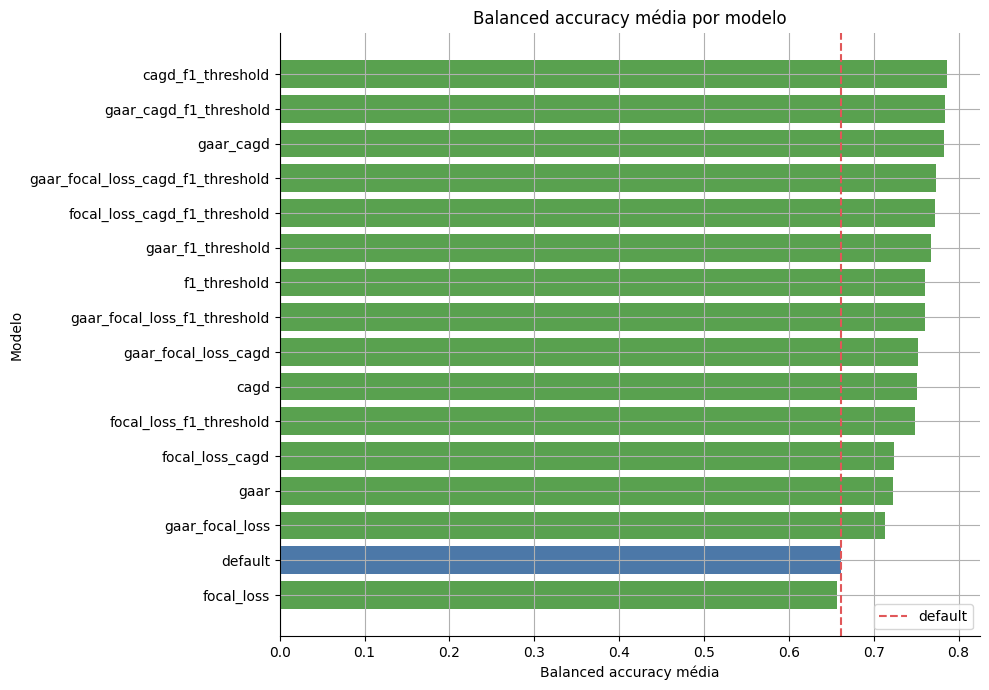

In [6]:
plot_df = model_summary.sort_values("balanced_accuracy_mean", ascending=True)
colors = ["#59A14F" if name != "default" else "#4C78A8" for name in plot_df["model"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df["model"], plot_df["balanced_accuracy_mean"], color=colors)
ax.set_title("Balanced accuracy média por modelo")
ax.set_xlabel("Balanced accuracy média")
ax.set_ylabel("Modelo")
ax.axvline(
    model_summary.loc[model_summary["model"] == "default", "balanced_accuracy_mean"].iloc[0],
    color="#E15759",
    linestyle="--",
    label="default",
)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparar várias métricas ao mesmo tempo

Um modelo pode melhorar uma métrica e piorar outra. Por exemplo, baixar o threshold pode aumentar o recall da classe minoritária, mas também pode criar mais falsos positivos.

Por isso, a próxima figura junta várias métricas. Cores mais claras indicam valores maiores.

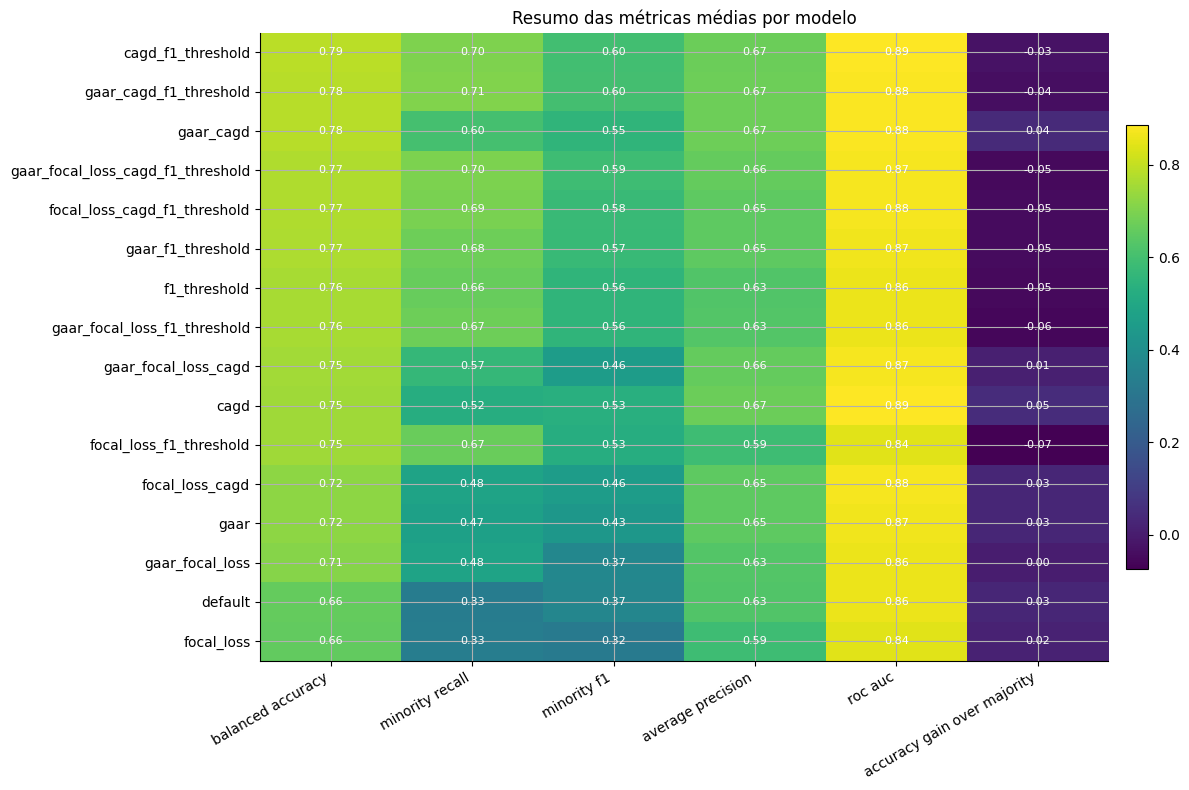

In [7]:
heatmap_metrics = [
    "balanced_accuracy_mean",
    "minority_recall_mean",
    "minority_f1_mean",
    "average_precision_mean",
    "roc_auc_mean",
    "accuracy_gain_over_majority_mean",
]

heatmap_df = (
    model_summary.set_index("model")
    .loc[model_order, heatmap_metrics]
)

fig, ax = plt.subplots(figsize=(12, 8))
image = ax.imshow(heatmap_df.values, aspect="auto", cmap="viridis")
ax.set_title("Resumo das métricas médias por modelo")
ax.set_xticks(np.arange(len(heatmap_metrics)))
ax.set_xticklabels([col.replace("_mean", "").replace("_", " ") for col in heatmap_metrics], rotation=30, ha="right")
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for row in range(heatmap_df.shape[0]):
    for col in range(heatmap_df.shape[1]):
        ax.text(col, row, f"{heatmap_df.iloc[row, col]:.2f}", ha="center", va="center", color="white", fontsize=8)

fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()

## 7. O compromisso entre encontrar positivos e manter qualidade geral

A classe minoritária é importante, mas não basta prever positivo em todo o lado. O gráfico seguinte mostra esse compromisso:

- eixo X: recall médio da classe maioritária;
- eixo Y: recall médio da classe minoritária;
- tamanho do ponto: F1 médio da classe minoritária.

O canto ideal seria perto do topo direito: encontrar muitos positivos e continuar a acertar muitos negativos.

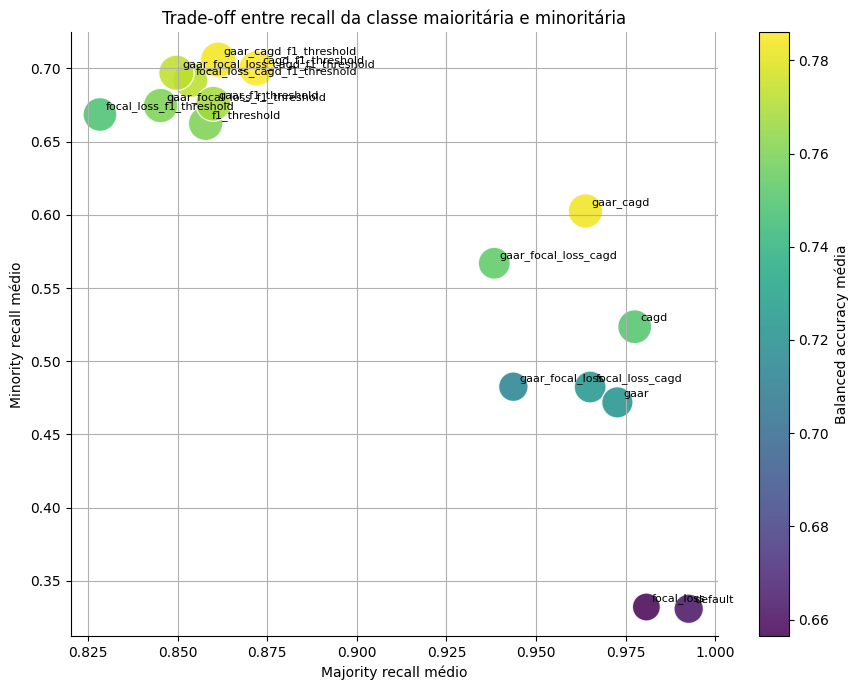

In [8]:
tradeoff = (
    raw_results.groupby("model", as_index=False)
    .agg(
        majority_recall_mean=("majority_recall", "mean"),
        minority_recall_mean=("minority_recall", "mean"),
        minority_f1_mean=("minority_f1", "mean"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(9, 7))
sizes = 120 + 900 * tradeoff["minority_f1_mean"]
scatter = ax.scatter(
    tradeoff["majority_recall_mean"],
    tradeoff["minority_recall_mean"],
    s=sizes,
    c=tradeoff["balanced_accuracy_mean"],
    cmap="viridis",
    alpha=0.85,
    edgecolor="white",
)

for _, row in tradeoff.iterrows():
    ax.annotate(row["model"], (row["majority_recall_mean"], row["minority_recall_mean"]), fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.set_title("Trade-off entre recall da classe maioritária e minoritária")
ax.set_xlabel("Majority recall médio")
ax.set_ylabel("Minority recall médio")
fig.colorbar(scatter, ax=ax, label="Balanced accuracy média")
plt.tight_layout()
plt.show()

## 8. Comparação emparelhada com o modelo `default`

A média por modelo é útil, mas ainda não responde a uma pergunta essencial:

> Quando comparo o add-on e o `default` exactamente no mesmo dataset e na mesma seed, o add-on melhora?

Para isso, o script calcula diferenças emparelhadas:

\[
\text{diferença} = \text{métrica do add-on} - \text{métrica do default}
\]

Se a diferença for positiva, o add-on ganhou naquele par dataset/seed. Se for negativa, perdeu.

A figura seguinte mostra a diferença média em balanced accuracy. As barras horizontais são intervalos de confiança por bootstrap.

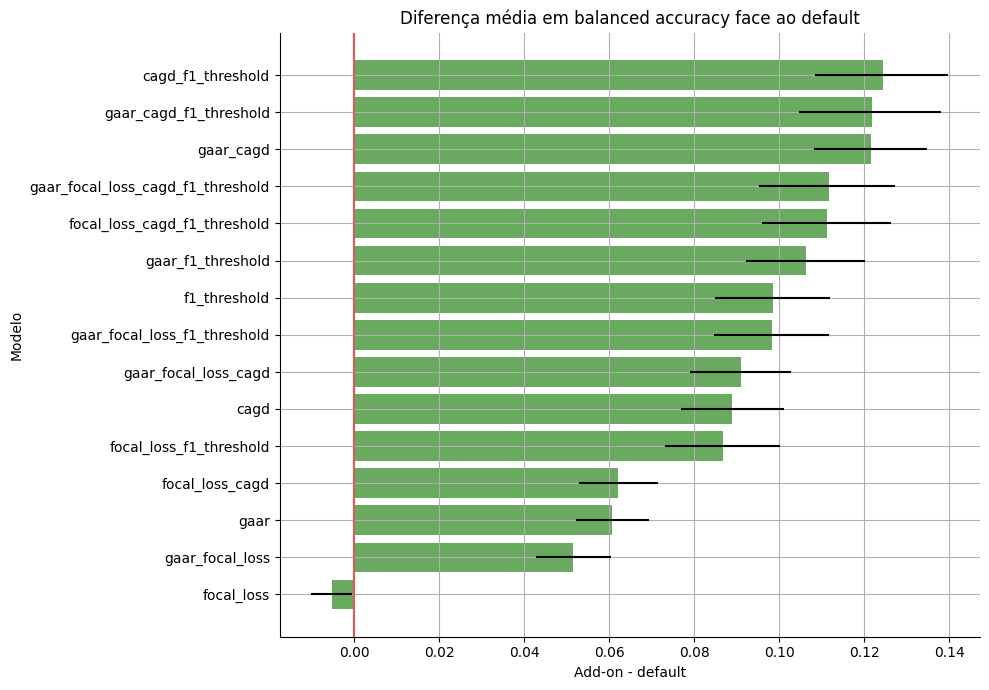

,model,n_pairs,mean_difference,bootstrap_ci_low,bootstrap_ci_high,wins,ties,losses,permutation_p_value,holm_p_value
44,focal_loss,385,-0.00530,-0.01004,-0.00062,48,201,136,0.0308,0.0308
40,gaar_focal_loss,385,0.05140,0.04273,0.06038,168,134,83,0.0001,0.0015
36,gaar,385,0.06055,0.05210,0.06923,204,137,44,0.0001,0.0015
33,focal_loss_cagd,385,0.06200,0.05293,0.07144,219,92,74,0.0001,0.0015
35,focal_loss_f1_threshold,385,0.08670,0.07303,0.10013,263,25,97,0.0001,0.0015
30,cagd,385,0.08881,0.07684,0.10101,229,106,50,0.0001,0.0015
41,gaar_focal_loss_cagd,385,0.09090,0.07907,0.10278,229,73,83,0.0001,0.0015
43,gaar_focal_loss_f1_threshold,385,0.09820,0.08453,0.11164,294,26,65,0.0001,0.0015
32,f1_threshold,385,0.09844,0.08475,0.11180,294,26,65,0.0001,0.0015
39,gaar_f1_threshold,385,0.10619,0.09216,0.12018,313,23,49,0.0001,0.0015


In [9]:
ba_tests = (
    paired_tests[paired_tests["metric"] == "balanced_accuracy"]
    .sort_values("mean_difference")
    .copy()
)

xerr = np.vstack([
    ba_tests["mean_difference"] - ba_tests["bootstrap_ci_low"],
    ba_tests["bootstrap_ci_high"] - ba_tests["mean_difference"],
])
colors = np.where(ba_tests["holm_p_value"] <= 0.05, "#59A14F", "#BAB0AC")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(ba_tests["model"], ba_tests["mean_difference"], xerr=xerr, color=colors, alpha=0.9)
ax.axvline(0, color="#E15759", linewidth=1.5)
ax.set_title("Diferença média em balanced accuracy face ao default")
ax.set_xlabel("Add-on - default")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.show()

display(
    ba_tests[[
        "model",
        "n_pairs",
        "mean_difference",
        "bootstrap_ci_low",
        "bootstrap_ci_high",
        "wins",
        "ties",
        "losses",
        "permutation_p_value",
        "holm_p_value",
    ]].round(5)
)

## 9. O que são estes testes estatísticos?

### Bootstrap interval

Temos várias diferenças emparelhadas, uma por dataset/seed. O bootstrap faz muitas reamostragens dessas diferenças e recalcula a média em cada amostra.

Em termos simples: é como perguntar "se eu repetisse este estudo com variações parecidas, onde poderia cair a média?". O intervalo `bootstrap_ci_low` a `bootstrap_ci_high` mostra essa zona provável.

Se o intervalo está todo acima de 0, é sinal de que a melhoria é bastante consistente.

### Sign test

O sign test ignora o tamanho da vitória e olha só para o sinal:

- ganhou;
- empatou;
- perdeu.

É uma pergunta simples: o modelo ganha mais vezes do que seria esperado por acaso?

### Paired permutation test

O teste de permutação parte da hipótese nula: "não há diferença sistemática entre o add-on e o default".

Se essa hipótese fosse verdade, trocar o sinal das diferenças ao acaso não deveria mudar muito a média. O script faz muitas trocas de sinal, cria uma distribuição de médias "por acaso" e vê se a diferença observada é extrema.

### Holm-Bonferroni

Este ponto é importante porque há muitos testes. Se fizermos 100 testes com nível de significância 0.05, alguns podem parecer significativos só por sorte.

Holm-Bonferroni corrige os p-values para controlar esse risco. O procedimento ordena os p-values do menor para o maior e aplica uma penalização mais forte aos menores. No script, esta correcção é feita separadamente para cada métrica.

Interpretação prática:

- `permutation_p_value` diz se a diferença parece improvável antes da correcção;
- `holm_p_value` é o valor a usar quando existem várias comparações;
- normalmente considero significativo quando `holm_p_value <= 0.05`.

In [10]:
significance_overview = (
    paired_tests.assign(significant=paired_tests["holm_p_value"] <= 0.05)
    .groupby("metric", as_index=False)
    .agg(
        tested_models=("model", "nunique"),
        significant_models=("significant", "sum"),
        best_mean_difference=("mean_difference", "max"),
        worst_mean_difference=("mean_difference", "min"),
    )
    .sort_values("metric")
)

display(significance_overview.round(5))

,metric,tested_models,significant_models,best_mean_difference,worst_mean_difference
0,accuracy_gain_over_majority,15,13,0.01660,-0.10435
1,average_precision,15,12,0.04924,-0.03510
2,balanced_accuracy,15,15,0.12428,-0.00530
3,minority_f1,15,14,0.23228,-0.04711
4,minority_recall,15,14,0.37501,0.00121
5,roc_auc,15,12,0.02810,-0.01478


## 10. Quais modelos ganham por dataset?

Até agora olhámos para médias globais. Mas datasets diferentes podem favorecer modelos diferentes.

A figura seguinte conta quantas vezes cada modelo foi o melhor em balanced accuracy ao nível do dataset.

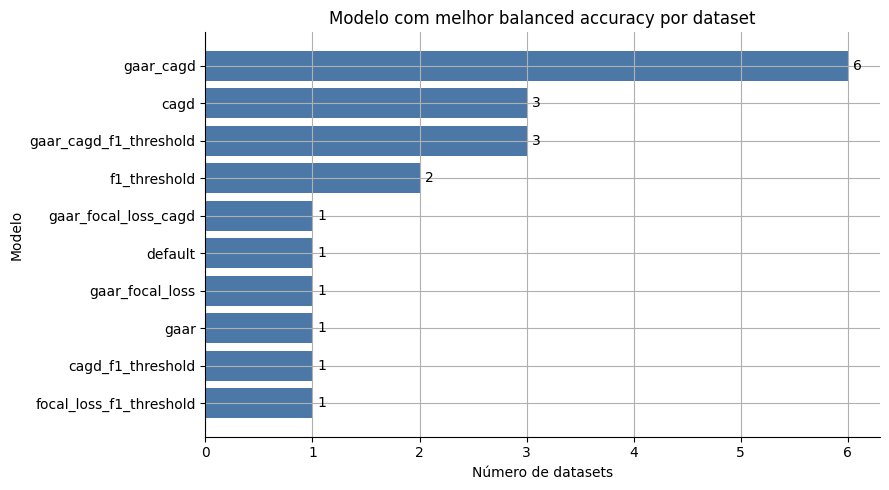

,dataset,best_balanced_accuracy_model,best_balanced_accuracy,default_balanced_accuracy,best_minority_f1_model,best_minority_f1,default_minority_f1
0,df1,gaar_focal_loss,0.6953,0.5104,gaar_f1_threshold,0.3569,0.0388
1,df10,gaar,0.9257,0.7877,gaar_f1_threshold,0.7395,0.6766
2,df11,gaar_cagd_f1_threshold,0.8517,0.7052,gaar_cagd,0.7384,0.5588
3,df12,gaar_cagd,0.9836,0.7799,gaar_cagd_f1_threshold,0.9567,0.7064
4,df13,cagd,0.5000,0.5000,gaar_focal_loss_f1_threshold,0.1467,0.0000
5,df14,f1_threshold,0.5473,0.5000,gaar_focal_loss_f1_threshold,0.1752,0.0000
6,df15,f1_threshold,0.7822,0.5000,f1_threshold,0.6449,0.0000
7,df16,gaar_cagd,0.8593,0.5000,gaar_cagd,0.7033,0.0000
8,df17,cagd_f1_threshold,0.8590,0.6635,gaar_cagd,0.7035,0.4797
9,df18,cagd,0.5000,0.5000,gaar_focal_loss_f1_threshold,0.0687,0.0000


In [11]:
winner_counts = (
    dataset_summary["best_balanced_accuracy_model"]
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(winner_counts.index, winner_counts.values, color="#4C78A8")
ax.set_title("Modelo com melhor balanced accuracy por dataset")
ax.set_xlabel("Número de datasets")
ax.set_ylabel("Modelo")
for index, value in enumerate(winner_counts.values):
    ax.text(value + 0.05, index, str(value), va="center")
plt.tight_layout()
plt.show()

display(dataset_summary[[
    "dataset",
    "best_balanced_accuracy_model",
    "best_balanced_accuracy",
    "default_balanced_accuracy",
    "best_minority_f1_model",
    "best_minority_f1",
    "default_minority_f1",
]].round(4))

## 11. Erros durante a experiência

O script não mistura execuções falhadas com resultados válidos. Quando um modelo produz probabilidades não finitas ou falha noutra etapa, o erro fica em `errors.csv` e essa linha não entra em `raw_results.csv`.

Isto é importante porque uma média só deve ser calculada com execuções realmente avaliadas. Ao mesmo tempo, os erros dizem-nos se algum dataset ou modelo é instável.

,dataset,model,error_type,erros
0,df18,cagd,FloatingPointError,15
1,df18,cagd_f1_threshold,FloatingPointError,15
2,df18,default,FloatingPointError,15
3,df18,f1_threshold,FloatingPointError,15
4,df18,focal_loss,FloatingPointError,15
5,df18,focal_loss_cagd,FloatingPointError,15
6,df18,focal_loss_cagd_f1_threshold,FloatingPointError,15
7,df18,focal_loss_f1_threshold,FloatingPointError,15
8,df18,gaar,FloatingPointError,15
9,df18,gaar_cagd,FloatingPointError,15


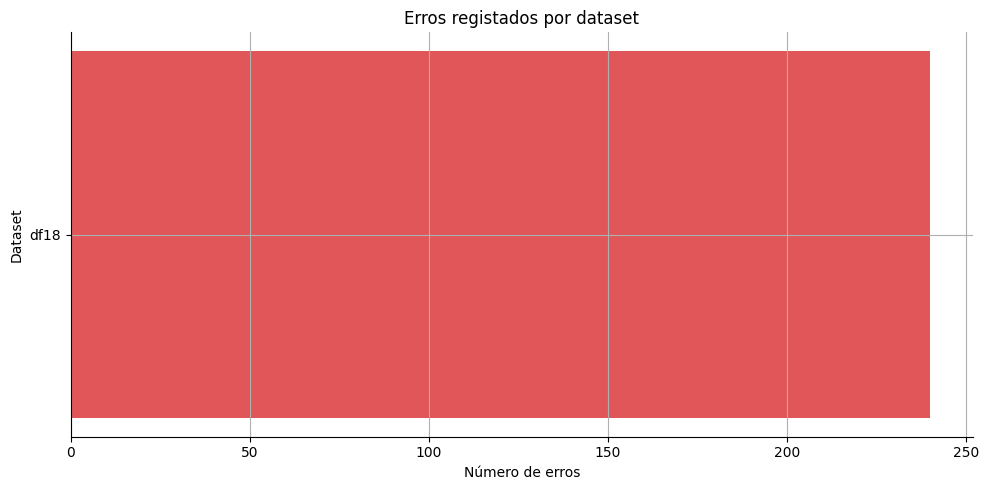

In [12]:
if errors.empty:
    print("Não houve erros registados.")
else:
    error_summary = (
        errors.groupby(["dataset", "model", "error_type"], as_index=False)
        .size()
        .rename(columns={"size": "erros"})
        .sort_values(["erros", "dataset", "model"], ascending=[False, True, True])
    )
    display(error_summary.head(30))

    fig, ax = plt.subplots(figsize=(10, 5))
    by_dataset = errors.groupby("dataset").size().sort_values()
    ax.barh(by_dataset.index, by_dataset.values, color="#E15759")
    ax.set_title("Erros registados por dataset")
    ax.set_xlabel("Número de erros")
    ax.set_ylabel("Dataset")
    plt.tight_layout()
    plt.show()

## 12. Leitura final dos resultados

A principal conclusão é que os add-ons com **CAGD** e **F1Threshold** aparecem no topo da balanced accuracy média. Isto faz sentido pelo desenho dos métodos:

- CAGD altera a forma como o treino dá passos no espaço dos parâmetros;
- F1Threshold ajusta a decisão final para favorecer um melhor F1 da classe positiva;
- juntos, atacam dois pontos diferentes do problema: treino e threshold.

Também se vê que melhorar a classe minoritária tem custo. Muitos modelos com threshold ajustado melhoram balanced accuracy e minority recall, mas podem ter `accuracy_gain_over_majority` negativo. Isto significa que, embora encontrem melhor a classe rara, perdem accuracy total face a uma baseline simples da classe maioritária.

Para um assignment de machine learning, eu escreveria a conclusão assim:

> A accuracy isolada é enganadora neste problema. As variantes com CAGD e threshold optimizado apresentaram o melhor compromisso médio para datasets desequilibrados, sobretudo em balanced accuracy e métricas da classe minoritária. A melhoria foi confirmada por testes emparelhados e correcção de Holm-Bonferroni para balanced accuracy. No entanto, esta melhoria vem frequentemente com perda de accuracy total, o que mostra o trade-off clássico em classificação desequilibrada: encontrar mais positivos implica aceitar mais falsos positivos.

O melhor modelo não deve ser escolhido só pelo maior número numa tabela. Deve ser escolhido pela métrica que corresponde ao custo real do problema. Se falhar positivos é caro, modelos com maior minority recall/F1 são preferíveis. Se falsos positivos forem muito caros, é preciso olhar com mais cuidado para precision, majority recall e a matriz de confusão.